In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim
import gensim.corpora as corpora

In [14]:
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

In [2]:
news_data = pd.read_csv('news_articles.csv')

In [3]:
news_data.head()

,id,title,content
0,25626,"One Weight-Loss Approach Fits All? No, Not Eve...","Dr. Frank Sacks, a professor of nutrition at H..."
1,19551,South Carolina Stuns Baylor to Reach the Round...,South Carolina’s win over Duke was not only ...
2,25221,"U.S. Presidential Race, Apple, Gene Wilder: Yo...",(Want to get this briefing by email? Here’s th...
3,18026,"His Predecessor Gone, Gambia’s New President F...","BANJUL, Gambia — A week after he was inaugu..."
4,21063,‘Harry Potter and the Cursed Child’ Goes From ...,The biggest book of the summer isn’t a blockbu...


In [4]:
article_content_df = news_data['content'].apply(lambda x: re.sub(r"([^\w\s])", "", x)).str.lower()

In [5]:
article_content_df.head()

0    dr frank sacks a professor of nutrition at har...
1    south carolinas win over   duke was not only a...
2    want to get this briefing by email heres the  ...
3    banjul gambia     a week after he was inaugura...
4    the biggest book of the summer isnt a blockbus...
Name: content, dtype: object

In [6]:
en_stopwords = stopwords.words("english")
article_content_df = article_content_df.apply(lambda x: " ".join([word for word in x.split() if word not in en_stopwords]))
article_content_df.head()

0    dr frank sacks professor nutrition harvard lik...
1    south carolinas win duke surprise fans postgam...
2    want get briefing email heres good evening her...
3    banjul gambia week inaugurated another country...
4    biggest book summer isnt blockbuster thriller ...
Name: content, dtype: object

In [7]:
article_content_df = article_content_df.apply(lambda x: word_tokenize(x))
article_content_df.head()

0    [dr, frank, sacks, professor, nutrition, harva...
1    [south, carolinas, win, duke, surprise, fans, ...
2    [want, get, briefing, email, heres, good, even...
3    [banjul, gambia, week, inaugurated, another, c...
4    [biggest, book, summer, isnt, blockbuster, thr...
Name: content, dtype: object

In [9]:
ps = PorterStemmer()
article_content_df = article_content_df.apply(lambda x: [ps.stem(token) for token in x])
article_content_df.head()

0    [dr, frank, sack, professor, nutrit, harvard, ...
1    [south, carolina, win, duke, surpri, fan, post...
2    [want, get, brief, email, here, good, even, he...
3    [banjul, gambia, week, inaugur, anoth, countri...
4    [biggest, book, summer, isnt, blockbust, thril...
Name: content, dtype: object

In [10]:
dictionary = corpora.Dictionary(article_content_df)

In [11]:
doc_term = [dictionary.doc2bow(doc) for doc in article_content_df]

In [12]:
num_topics = 4
lda_model = gensim.models.LdaModel(corpus=doc_term,
                                   id2word=dictionary,
                                   num_topics=num_topics)

In [13]:
lda_model.print_topics(num_topics=num_topics, num_words=5)

[(0, '0.015*"mr" + 0.011*"said" + 0.004*"state" + 0.004*"trump" + 0.004*"ms"'),
 (1,
  '0.016*"said" + 0.016*"mr" + 0.004*"trump" + 0.004*"would" + 0.004*"one"'),
 (2, '0.015*"said" + 0.014*"mr" + 0.005*"year" + 0.005*"trump" + 0.004*"one"'),
 (3,
  '0.022*"mr" + 0.016*"said" + 0.008*"trump" + 0.006*"would" + 0.004*"state"')]

In [15]:
# generate coherence scores to determine an optimum number of topics
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = LsiModel(doc_term, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=article_content_df, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

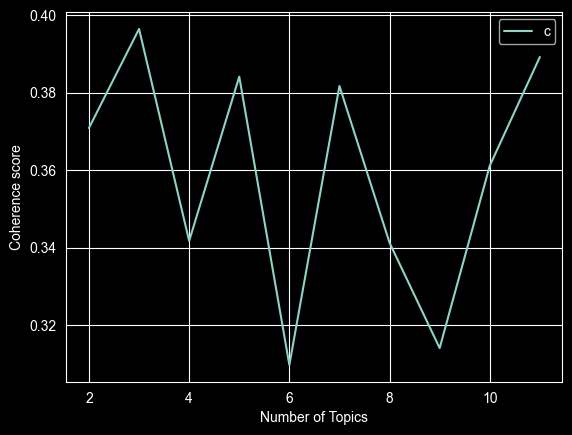

In [16]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()